# 🏠 Dự Đoán Giá Nhà California — Linear Regression
**Nguồn dữ liệu:** [California Housing Prices](https://necromuralist.github.io/machine-learning-studies/posts/california-housing-prices/)  
**Mục tiêu:** Xây dựng mô hình hồi quy tuyến tính dự đoán `median_house_value` dựa trên các đặc trưng từ điều tra dân số California 1990.

---
## Mục Lục
1. Lý Thuyết Linear Regression
2. Cài Đặt & Import Thư Viện
3. Tải & Khám Phá Dữ Liệu (EDA)
4. Tiền Xử Lý Dữ Liệu
5. Xây Dựng & Huấn Luyện Mô Hình
6. Đánh Giá Mô Hình
7. Trực Quan Hóa Loss & Dự Đoán
8. Lưu & Tải Mô Hình
9. Kết Luận


## 1. Lý Thuyết Linear Regression

### 1.1 Định Nghĩa
**Hồi quy tuyến tính (Linear Regression)** là thuật toán học có giám sát dự đoán giá trị liên tục, giả định mối quan hệ tuyến tính giữa $X$ và $y$.

### 1.2 Hàm Giả Thuyết
$$\hat{y} = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n = \mathbf{X}\boldsymbol{\theta}$$

### 1.3 Hàm Mất Mát — MSE
$$\mathcal{L} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$

### 1.4 Gradient Descent
$$\theta_j := \theta_j - \alpha \cdot \frac{\partial \mathcal{L}}{\partial \theta_j}, \quad \frac{\partial \mathcal{L}}{\partial \theta_j} = \frac{2}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})x_j^{(i)}$$

### 1.5 Normal Equation (Nghiệm Giải Tích)
$$\boldsymbol{\theta}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

### 1.6 Các Chỉ Số Đánh Giá
| Chỉ số | Công thức | Ý nghĩa |
|--------|-----------|----------|
| MSE | $\frac{1}{m}\sum(\hat{y}-y)^2$ | Sai số bình phương trung bình |
| RMSE | $\sqrt{MSE}$ | Sai số cùng đơn vị với $y$ |
| MAE | $\frac{1}{m}\sum|\hat{y}-y|$ | Sai số tuyệt đối trung bình |
| $R^2$ | $1-\frac{SS_{res}}{SS_{tot}}$ | Tỷ lệ phương sai giải thích được |


## 2. Import Thư Viện


In [26]:
# === IMPORTS & SETUP ===
import os
import warnings
import requests
import tarfile
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sc_stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

# Tạo thư mục output ngay khi import
os.makedirs('plots',  exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data',   exist_ok=True)

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
PALETTE = ['#00d4ff', '#ff6b6b', '#7bed9f', '#ffa502', '#eccc68', '#a29bfe']

print('Các thư mục đã được tạo:')
for d in ['plots', 'models', 'data']:
    print(f'  {d}/ -> {os.path.abspath(d)}')
print('Thư viện import thành công!')


Các thư mục đã được tạo:
  plots/ -> c:\Users\minht\OneDrive\Desktop\LinearRegression\plots
  models/ -> c:\Users\minht\OneDrive\Desktop\LinearRegression\models
  data/ -> c:\Users\minht\OneDrive\Desktop\LinearRegression\data
Thư viện import thành công!


## 3. Tải & Khám Phá Dữ Liệu (EDA)

### 3.1 Nguồn Dữ Liệu
Dataset California Housing 1990 Census với **20,640 district**. Tải từ GitHub của Aurélien Géron (cùng nguồn được tham chiếu tại necromuralist.github.io).

| Cột | Mô tả |
|-----|-------|
| `longitude` | Kinh độ |
| `latitude` | Vĩ độ |
| `housing_median_age` | Tuổi trung vị của nhà |
| `total_rooms` | Tổng số phòng |
| `total_bedrooms` | Tổng số phòng ngủ (có giá trị thiếu - missing) |
| `population` | Dân số district |
| `households` | Số hộ gia đình |
| `median_income` | Thu nhập trung vị (đơn vị x$10.000) |
| `median_house_value` | **Giá nhà trung vị — TARGET (Mục tiêu biến)** |
| `ocean_proximity` | Khoảng cách đến biển (biến phân loại categorical) |


In [27]:
DATA_URL = 'https://github.com/ageron/handson-ml/raw/master/datasets/housing/housing.tgz'
DATA_TGZ = os.path.join('data', 'housing.tgz')
DATA_CSV = os.path.join('data', 'housing.csv')

def fetch_housing_data():
    if not os.path.exists(DATA_CSV):
        print('Đang tải dữ liệu...')
        r = requests.get(DATA_URL, stream=True, timeout=60)
        with open(DATA_TGZ, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024):
                f.write(chunk)
        with tarfile.open(DATA_TGZ) as tf:
            tf.extractall('data')
        print('Tải xong!')
    else:
        print('File đã tồn tại, bỏ qua tải.')

fetch_housing_data()
df = pd.read_csv(DATA_CSV)
print(f'Shape kích thước dữ liệu: {df.shape}')
df.head()


File đã tồn tại, bỏ qua tải.
Shape kích thước dữ liệu: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
print('=== Thông tin dữ liệu ===')
df.info()
print('\n=== Thống kê mô tả ===')
df.describe().round(2)


=== Thông tin dữ liệu ===
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

=== Thống kê mô tả ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [29]:
missing = df.isnull().sum()
print('=== Giá trị thiếu (Missing Values) ===')
print(missing[missing > 0])
print(f'\nTỷ lệ thiếu total_bedrooms: {df.total_bedrooms.isna().mean()*100:.2f}%')


=== Giá trị thiếu (Missing Values) ===
total_bedrooms    207
dtype: int64

Tỷ lệ thiếu total_bedrooms: 1.00%


### 3.2 Phân Phối Biến Mục Tiêu


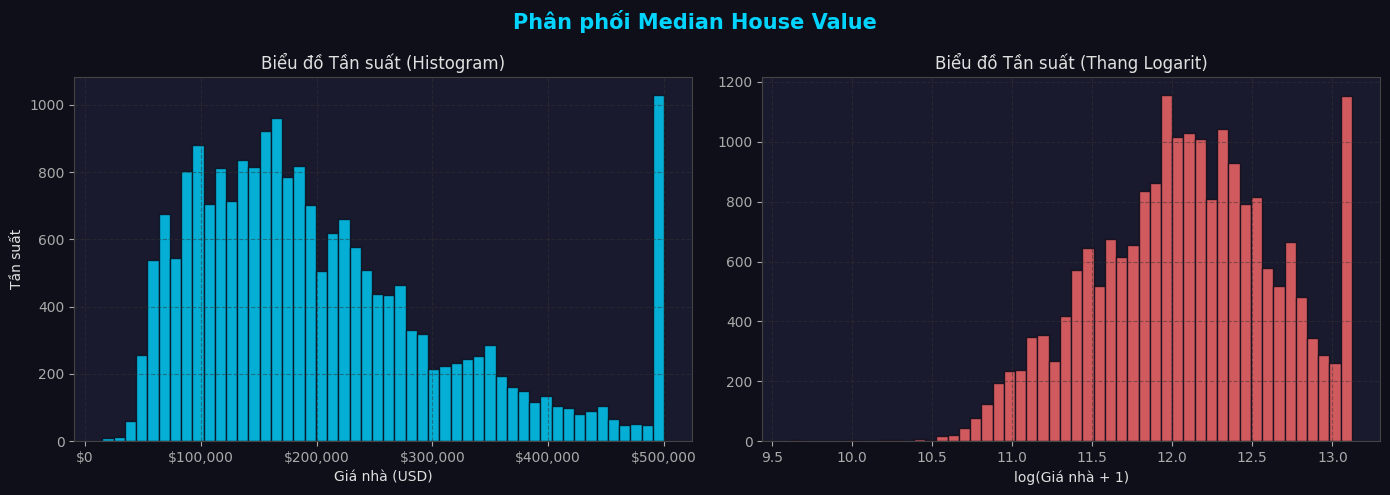

Giá nhà trung vị: $179,700
Giá nhà trung bình: $206,856


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối Median House Value', fontsize=15, fontweight='bold', color='#00d4ff')

axes[0].hist(df['median_house_value'], bins=50, color='#00d4ff', alpha=0.8, edgecolor='#0a0a1a')
axes[0].set_title('Biểu đồ Tần suất (Histogram)')
axes[0].set_xlabel('Giá nhà (USD)')
axes[0].set_ylabel('Tần suất')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True)

axes[1].hist(np.log1p(df['median_house_value']), bins=50, color='#ff6b6b', alpha=0.8, edgecolor='#0a0a1a')
axes[1].set_title('Biểu đồ Tần suất (Thang Logarit)')
axes[1].set_xlabel('log(Giá nhà + 1)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Giá nhà trung vị: ${df["median_house_value"].median():,.0f}')
print(f'Giá nhà trung bình: ${df["median_house_value"].mean():,.0f}')


### 3.3 Bản Đồ Địa Lý


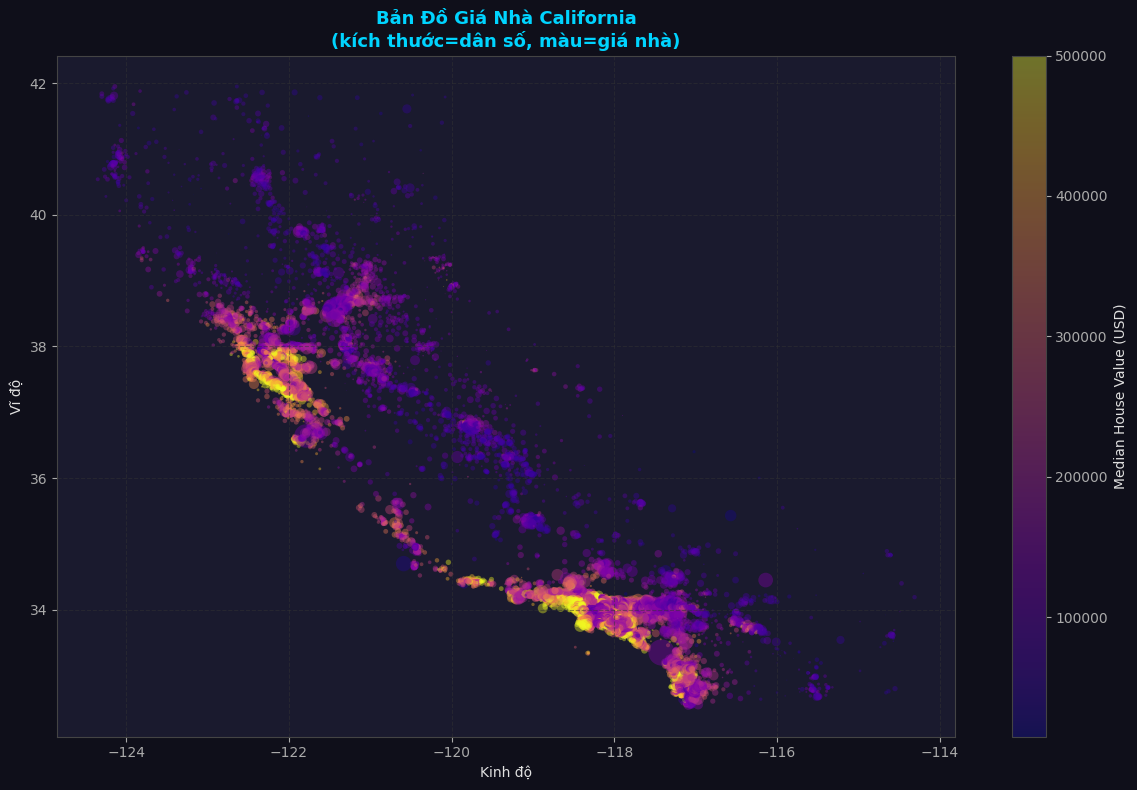

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'], cmap='plasma',
    alpha=0.4, s=df['population']/100, linewidths=0
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Median House Value (USD)', color='#e0e0e0')
ax.set_title('Bản Đồ Giá Nhà California\n(kích thước=dân số, màu=giá nhà)',
             fontsize=13, fontweight='bold', color='#00d4ff')
ax.set_xlabel('Kinh độ')
ax.set_ylabel('Vĩ độ')
ax.grid(True)
plt.tight_layout()
plt.savefig('plots/02_geo_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Ma Trận Tương Quan


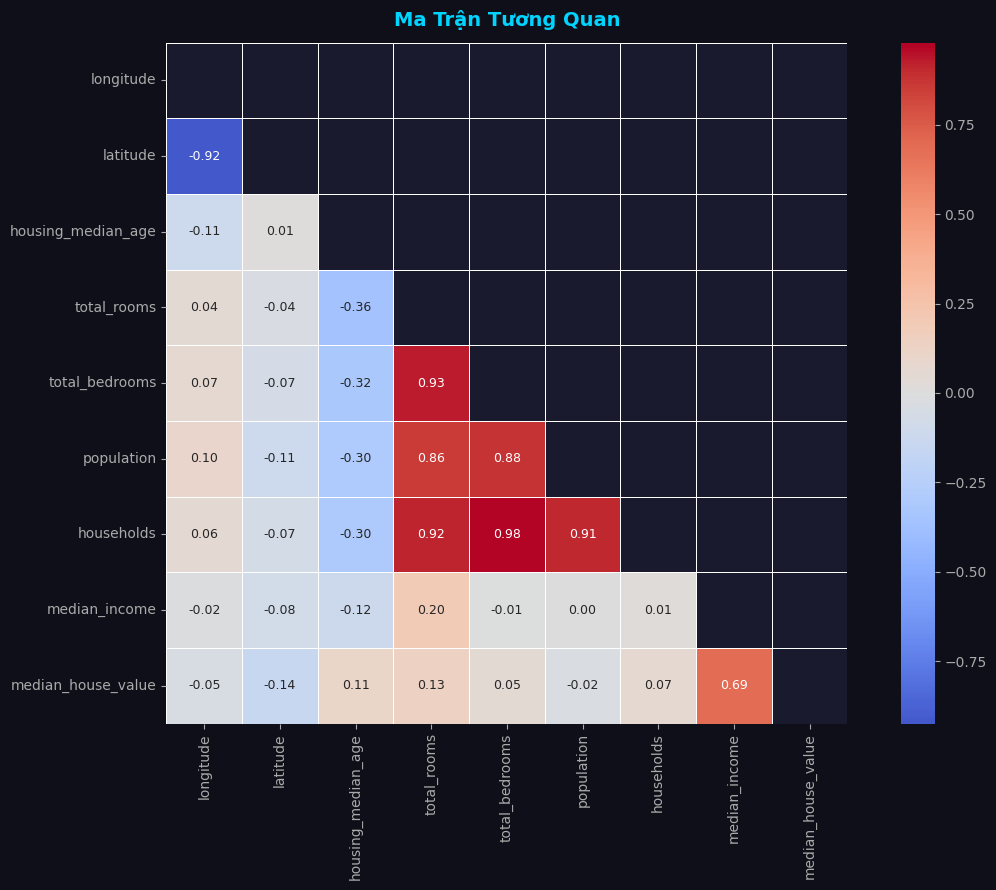


Tương quan với median_house_value (Giá nhà):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160


In [32]:
corr = df.drop(columns='ocean_proximity').corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Ma Trận Tương Quan', fontsize=14, fontweight='bold', color='#00d4ff', pad=12)
plt.tight_layout()
plt.savefig('plots/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTương quan với median_house_value (Giá nhà):')
print(corr['median_house_value'].sort_values(ascending=False).to_string())


### 3.5 Đặc Trưng Khu Vực Biển (Ocean Proximity)


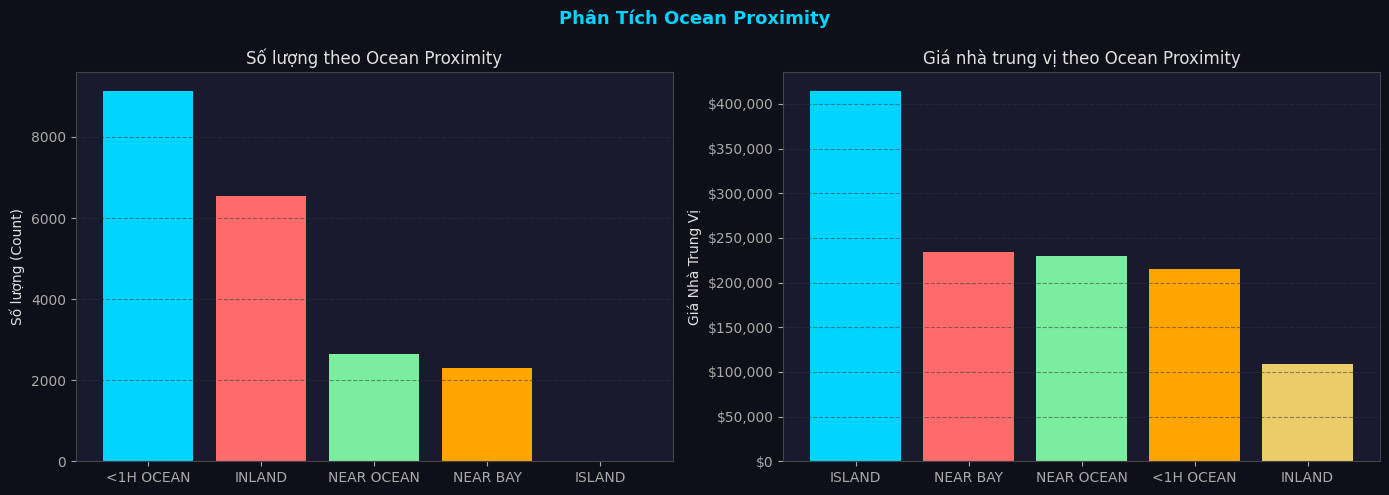

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df['ocean_proximity'].value_counts()
axes[0].bar(vc.index, vc.values, color=PALETTE[:len(vc)])
axes[0].set_title('Số lượng theo Ocean Proximity')
axes[0].set_ylabel('Số lượng (Count)'); axes[0].grid(True, axis='y')

grp = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False)
axes[1].bar(grp.index, grp.values, color=PALETTE[:len(grp)])
axes[1].set_title('Giá nhà trung vị theo Ocean Proximity')
axes[1].set_ylabel('Giá Nhà Trung Vị')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(True, axis='y')
plt.suptitle('Phân Tích Ocean Proximity', fontsize=13, fontweight='bold', color='#00d4ff')
plt.tight_layout()
plt.savefig('plots/04_ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Tiền Xử Lý Dữ Liệu

| Bước | Vấn đề | Giải pháp |
|------|--------|----------|
| 1 | Giá trị thiếu (total_bedrooms) | Điền bằng trung vị (median) |
| 2 | Loại dữ liệu phân loại (ocean_proximity) | Mã hóa One-Hot Encoding |
| 3 | Trích xuất đặc trưng (Feature Engineering) | Tạo 3 đặc trưng mới (feature) |
| 4 | Chênh lệch độ lớn dữ liệu (Scale) | Chuẩn hóa biến qua StandardScaler |
| 5 | Chia tập dữ liệu | Train 70 / Val 15 / Test 15 |


In [34]:
df_proc = df.copy()

# Điền missing
med_bed = df_proc['total_bedrooms'].median()
df_proc['total_bedrooms'] = df_proc['total_bedrooms'].fillna(med_bed)
print(f'Điền khuyết thiếu total_bedrooms = {med_bed}')

# Feature Engineering (Đặc trưng mới)
df_proc['rooms_per_household']      = df_proc['total_rooms']    / df_proc['households']
df_proc['bedrooms_per_room']        = df_proc['total_bedrooms'] / df_proc['total_rooms']
df_proc['population_per_household'] = df_proc['population']     / df_proc['households']
print('Feature Engineering: 3 features mới đã được tạo')

# One-Hot Encoding
df_proc = pd.get_dummies(df_proc, columns=['ocean_proximity'], drop_first=False)
ocean_cols = [c for c in df_proc.columns if 'ocean_proximity' in c]
print('Các cột One-Hot mới:', ocean_cols)


Điền khuyết thiếu total_bedrooms = 435.0
Feature Engineering: 3 features mới đã được tạo
Các cột One-Hot mới: ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [35]:
TARGET = 'median_house_value'
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]
print(f'Số Đặc trưng (Features): {X.shape[1]} | Số Hàng: {len(X)}')
print(list(X.columns))


Số Đặc trưng (Features): 16 | Số Hàng: 20640
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [36]:
# Chia Train / Val / Test (70% / 15% / 15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

print('=== Phân Chia Tập Dữ Liệu ===')
print(f'Train:      {X_train.shape[0]:>6} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]:>6} mẫu ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:       {X_test.shape[0]:>6} mẫu ({X_test.shape[0]/len(X)*100:.1f}%)')


=== Phân Chia Tập Dữ Liệu ===
Train:       14447 mẫu (70.0%)
Validation:   3097 mẫu (15.0%)
Test:         3096 mẫu (15.0%)


In [37]:
# Chuẩn Hóa Dữ Liệu
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print('Chuẩn hóa StandardScaler hoàn tất!')
print(f'Giá trị TB (3 đặc trưng đầu): {X_train_s.mean(axis=0)[:3].round(4)}')
print(f'Độ lệch chuẩn (3 đặc trưng đầu): {X_train_s.std(axis=0)[:3].round(4)}')


Chuẩn hóa StandardScaler hoàn tất!
Giá trị TB (3 đặc trưng đầu): [0. 0. 0.]
Độ lệch chuẩn (3 đặc trưng đầu): [1. 1. 1.]


## 5. Xây Dựng & Huấn Luyện Mô Hình

### 5.1 Sklearn LinearRegression (Normal Equation - Phương Trình Pháp Tuyến)
Phần lớn Sklearn dùng phương pháp SVD toán học để giải trực tiếp nghiệm tối ưu.


In [38]:
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)

y_pred_train_lr = lr_model.predict(X_train_s)
y_pred_val_lr   = lr_model.predict(X_val_s)

mse_train = mean_squared_error(y_train, y_pred_train_lr)
mse_val   = mean_squared_error(y_val,   y_pred_val_lr)

print('=== Thư viện Sklearn LinearRegression ===')
print(f'Train | MSE: {mse_train:>14,.2f} | RMSE: {np.sqrt(mse_train):>10,.2f} | R2: {r2_score(y_train, y_pred_train_lr):.4f}')
print(f'Val   | MSE: {mse_val:>14,.2f} | RMSE: {np.sqrt(mse_val):>10,.2f} | R2: {r2_score(y_val, y_pred_val_lr):.4f}')


=== Thư viện Sklearn LinearRegression ===
Train | MSE: 4,579,477,565.07 | RMSE:  67,671.84 | R2: 0.6569
Val   | MSE: 4,533,700,141.97 | RMSE:  67,332.76 | R2: 0.6611


### 5.2 Gradient Descent Tự Lập Trình (Mini-Batch Numpy)
Lập trình tự động cơ chế Mini-Batch Gradient Descent kết hợp Dừng Sớm (Early Stopping) để hiểu rõ ràng cấu trúc cập nhật tham số máy học.


In [39]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, n_epochs=200, batch_size=256, patience=20):
        self.lr=lr; self.n_epochs=n_epochs
        self.batch_size=batch_size; self.patience=patience
        self.train_losses=[]; self.val_losses=[]

    def fit(self, X, y, X_val=None, y_val=None):
        m, n = X.shape
        self.W = np.zeros(n); self.b = 0.0
        best_val, no_imp, best_ep = np.inf, 0, 0
        self.best_W, self.best_b = self.W.copy(), self.b

        # In Bảng Nhật Ký Huấn Luyện
        print('='*72)
        print('{:>8} | {:>22} | {:>22} | {:>10}'.format('EPOCH', 'TRAIN RMSE (Lỗi)', 'VAL RMSE (Lỗi)', 'TRẠNG THÁI'))
        print('-'*72)

        for epoch in range(1, self.n_epochs+1):
            idx = np.random.permutation(m)
            Xs, ys = X[idx], y[idx]
            for s in range(0, m, self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                err = Xb@self.W + self.b - yb
                nb = len(yb)
                self.W -= self.lr*(2/nb)*(Xb.T@err)
                self.b -= self.lr*(2/nb)*err.sum()

            tl = np.mean((X@self.W+self.b - y)**2)
            self.train_losses.append(tl)

            status = ''
            if X_val is not None:
                vl = np.mean((X_val@self.W+self.b - y_val)**2)
                self.val_losses.append(vl)
                if vl < best_val:
                    best_val=vl; no_imp=0; best_ep=epoch
                    self.best_W=self.W.copy(); self.best_b=self.b
                    status = '⭐ TỐT NHẤT'
                else:
                    no_imp+=1
                
                # In chi tiết mỗi 10 epoch hoặc khi đạt kỷ lục hoặc khi dừng sớm
                if epoch <= 10 or epoch % 10 == 0 or status == '⭐ TỐT NHẤT' or no_imp >= self.patience:
                    print('{:8} | {:>22,.2f} | {:>22,.2f} | {:>10}'.format(epoch, np.sqrt(tl), np.sqrt(vl), status))

                if no_imp >= self.patience:
                    print('-'*72)
                    print(f'🛑 Early stopping! Đã dừng sớm vì không thể vượt qua kỷ lục tại Epoch {best_ep}')
                    break

        self.W, self.b = self.best_W, self.best_b
        print('='*72)
        print(f'🏆 Kết quả chốt: Chọn Epoch [{best_ep}] vì có Val RMSE thấp nhất: {np.sqrt(best_val):,.2f}')
        print('='*72)
        return self

    def predict(self, X):
        return X@self.W + self.b

print('Class LinearRegressionGD (Gradient Descent Tự Lập Trình) định nghĩa xong!')


Class LinearRegressionGD (Gradient Descent Tự Lập Trình) định nghĩa xong!


In [40]:
gd_model = LinearRegressionGD(lr=0.05, n_epochs=300, batch_size=512, patience=20)
gd_model.fit(X_train_s, y_train.values, X_val=X_val_s, y_val=y_val.values)

y_pred_val_gd = gd_model.predict(X_val_s)
mse_vl_gd = mean_squared_error(y_val, y_pred_val_gd)

print('\n=== LinearRegressionGD ===')
print(f'Val | MSE: {mse_vl_gd:>14,.2f} | RMSE: {np.sqrt(mse_vl_gd):>10,.2f} | R2: {r2_score(y_val, y_pred_val_gd):.4f}')


   EPOCH |       TRAIN RMSE (Lỗi) |         VAL RMSE (Lỗi) | TRẠNG THÁI
------------------------------------------------------------------------
       1 |              71,837.71 |              71,928.98 | ⭐ TỐT NHẤT
       2 |              69,382.47 |              69,284.98 | ⭐ TỐT NHẤT
       3 |              68,847.24 |              68,659.01 | ⭐ TỐT NHẤT
       4 |              68,492.62 |              68,344.64 | ⭐ TỐT NHẤT
       5 |              68,445.38 |              68,438.70 |           
       6 |              68,231.79 |              68,109.25 | ⭐ TỐT NHẤT
       7 |              68,254.36 |              67,803.13 | ⭐ TỐT NHẤT
       8 |              68,139.27 |              68,001.27 |           
       9 |              68,080.05 |              67,862.79 |           
      10 |              68,007.22 |              67,781.47 | ⭐ TỐT NHẤT
      13 |              67,894.92 |              67,673.20 | ⭐ TỐT NHẤT
      15 |              67,908.19 |              67,464.40 | ⭐ 

### 5.3 SGDRegressor (Hàm Thư Viện Sklearn)


In [41]:
sgd_model = SGDRegressor(
    max_iter=1000, tol=1e-4, learning_rate='invscaling',
    eta0=0.01, random_state=42,
    early_stopping=True, validation_fraction=0.15, n_iter_no_change=20
)
sgd_model.fit(X_train_s, y_train)
y_pred_val_sgd = sgd_model.predict(X_val_s)
mse_sgd = mean_squared_error(y_val, y_pred_val_sgd)
r2_sgd  = r2_score(y_val, y_pred_val_sgd)
print(f'SGDRegressor Val | MSE: {mse_sgd:>12,.2f} | RMSE: {np.sqrt(mse_sgd):>10,.2f} | R2: {r2_sgd:.4f}')
print(f'Số vòng lặp thực tế đã luyện: {sgd_model.n_iter_}')


SGDRegressor Val | MSE: 530,308,569,234,801,557,504.00 | RMSE: 23,028,429,586.81 | R2: -39639211848.0541
Số vòng lặp thực tế đã luyện: 21


## 6. Đánh Giá Mô Hình
### 6.1 Kiểm tra chéo Cross-Validation (5-Fold)


In [42]:
pipe = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
cv  = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv)
print('=== 5-Fold CV RMSE ===')
for i, v in enumerate(cv_rmse, 1):
    print(f'  Lần Test {i}: {v:>10,.2f}')
print(f'  Trung Bình : {cv_rmse.mean():>10,.2f}')
print(f'  Độ Lệch Chuẩn: {cv_rmse.std():>10,.2f}')


=== 5-Fold CV RMSE ===
  Lần Test 1:  73,391.42
  Lần Test 2:  74,809.28
  Lần Test 3:  75,434.26
  Lần Test 4:  76,604.36
  Lần Test 5:  66,196.72
  Trung Bình :  73,287.21
  Độ Lệch Chuẩn:   3,693.67


### 6.2 Bảng So Sánh 3 Mô Hình


In [43]:
y_pred_test = lr_model.predict(X_test_s)
test_mse  = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae  = mean_absolute_error(y_test, y_pred_test)
test_r2   = r2_score(y_test, y_pred_test)

rows = [
    ['LinearRegression Thư Viện (Công thức chuẩn)',
     f'{np.sqrt(mse_val):,.2f}', f'{mean_absolute_error(y_val, y_pred_val_lr):,.2f}',
     f'{r2_score(y_val, y_pred_val_lr):.4f}'],
    ['LinearRegressionGD Tự Lập Trình',
     f'{np.sqrt(mse_vl_gd):,.2f}', f'{mean_absolute_error(y_val, y_pred_val_gd):,.2f}',
     f'{r2_score(y_val, y_pred_val_gd):.4f}'],
    ['SGDRegressor Thư Viện',
     f'{np.sqrt(mse_sgd):,.2f}', f'{mean_absolute_error(y_val, y_pred_val_sgd):,.2f}',
     f'{r2_sgd:.4f}'],
]
df_cmp = pd.DataFrame(rows, columns=['Mô hình Phương Pháp','Val Tập Xác Thực RMSE','Val Tập Xác Thực MAE','Val R2'])
print('=== SO SÁNH TRÊN TẬP XÁC THỰC (VALIDATION SET) ===')
print(df_cmp.to_string(index=False))
print(f'\n=== TẬP KIỂM THỬ THỰC SỰ (TEST SET) BẰNG LinearRegression ===')
print(f'MSE  : {test_mse:>15,.2f}')
print(f'RMSE : {test_rmse:>15,.2f} USD')
print(f'MAE  : {test_mae:>15,.2f} USD')
print(f'R2   : {test_r2:>15.4f}')


=== SO SÁNH TRÊN TẬP XÁC THỰC (VALIDATION SET) ===
                        Mô hình Phương Pháp Val Tập Xác Thực RMSE Val Tập Xác Thực MAE            Val R2
LinearRegression Thư Viện (Công thức chuẩn)             67,332.76            49,138.07            0.6611
            LinearRegressionGD Tự Lập Trình             67,217.84            49,120.47            0.6623
                      SGDRegressor Thư Viện     23,028,429,586.81     2,296,955,778.60 -39639211848.0541

=== TẬP KIỂM THỬ THỰC SỰ (TEST SET) BẰNG LinearRegression ===
MSE  : 5,530,003,286.62
RMSE :       74,363.99 USD
MAE  :       51,860.26 USD
R2   :          0.5780


### 6.3 Mức Độ Quan Trọng Của Các Yếu Tố (Feature Importance) - Hệ Số Hồi Quy


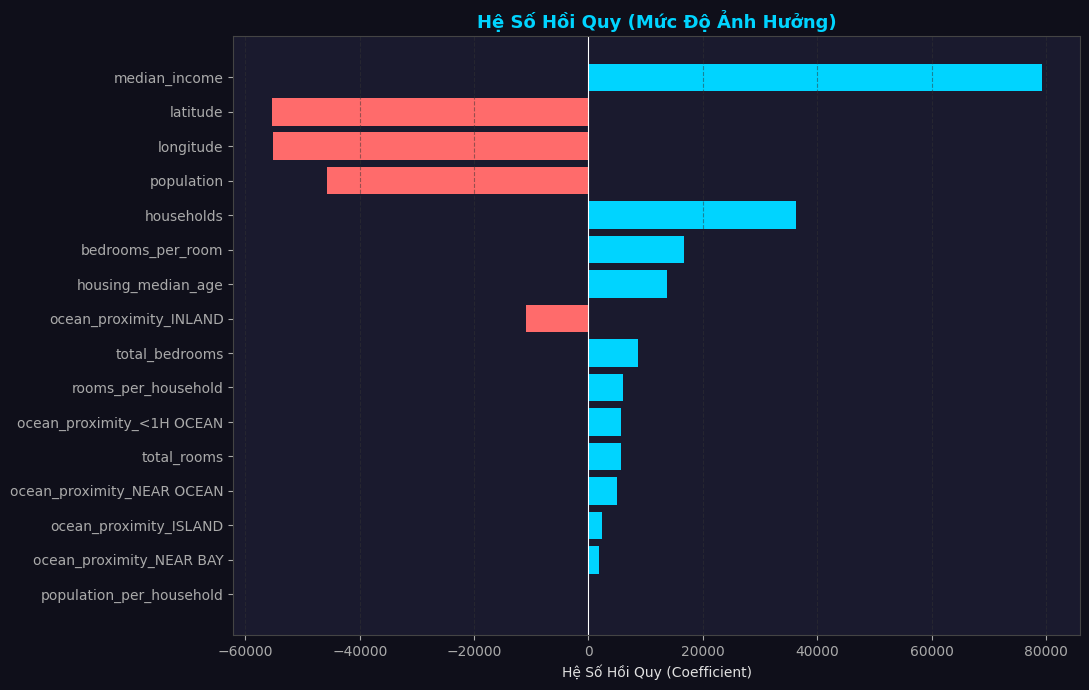

In [44]:
feat_df = pd.DataFrame({'Đặc_Trưng_Feature': X.columns, 'Hệ_Số_Coefficient': lr_model.coef_})
feat_df['TuyệtĐối'] = feat_df['Hệ_Số_Coefficient'].abs()
feat_df = feat_df.sort_values('TuyệtĐối', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#00d4ff' if c > 0 else '#ff6b6b' for c in feat_df['Hệ_Số_Coefficient']]
ax.barh(feat_df['Đặc_Trưng_Feature'], feat_df['Hệ_Số_Coefficient'], color=colors)
ax.axvline(0, color='white', lw=0.8)
ax.set_title('Hệ Số Hồi Quy (Mức Độ Ảnh Hưởng)', fontsize=13, fontweight='bold', color='#00d4ff')
ax.set_xlabel('Hệ Số Hồi Quy (Coefficient)')
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('plots/05_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Trực Quan Hóa Quá Trình & Dự Đoán
### 7.1 Đường Cong Học Tập (Learning Curves - Gradient Descent)


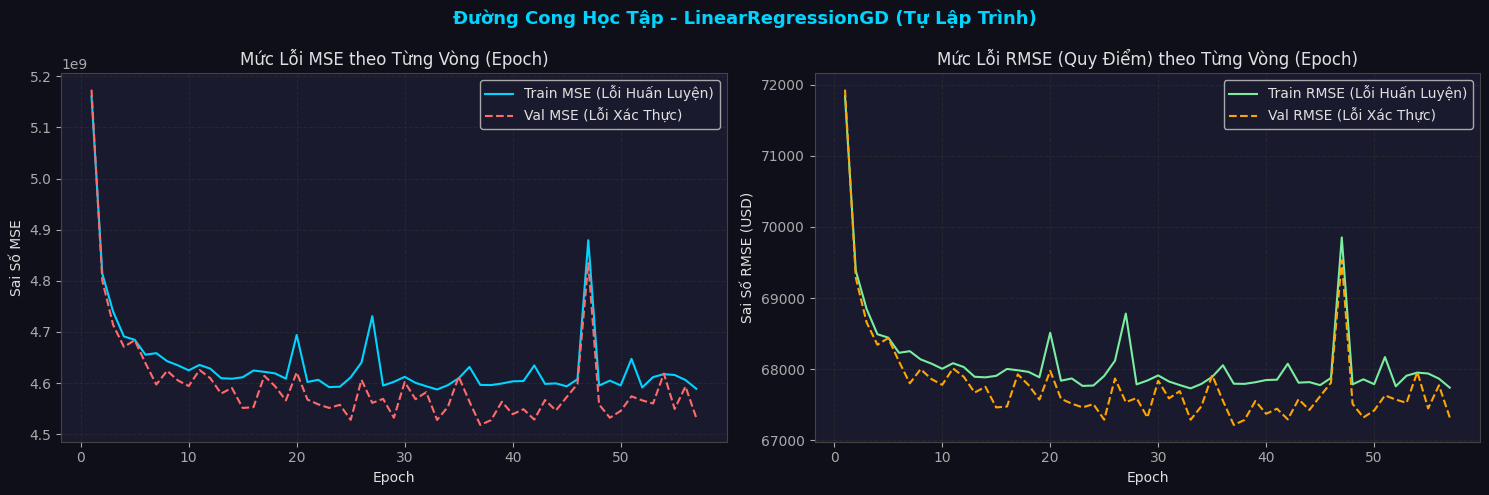

Train RMSE kết thúc: 67,742.39 | Val RMSE kết thúc: 67,322.85


In [45]:
ep = range(1, len(gd_model.train_losses)+1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Đường Cong Học Tập - LinearRegressionGD (Tự Lập Trình)', fontsize=13, fontweight='bold', color='#00d4ff')

axes[0].plot(ep, gd_model.train_losses, color='#00d4ff', label='Train MSE (Lỗi Huấn Luyện)')
axes[0].plot(ep, gd_model.val_losses,   color='#ff6b6b', label='Val MSE (Lỗi Xác Thực)', ls='--')
axes[0].set_title('Mức Lỗi MSE theo Từng Vòng (Epoch)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Sai Số MSE')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, np.sqrt(gd_model.train_losses), color='#7bed9f', label='Train RMSE (Lỗi Huấn Luyện)')
axes[1].plot(ep, np.sqrt(gd_model.val_losses),   color='#ffa502', label='Val RMSE (Lỗi Xác Thực)', ls='--')
axes[1].set_title('Mức Lỗi RMSE (Quy Điểm) theo Từng Vòng (Epoch)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Sai Số RMSE (USD)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('plots/06_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Train RMSE kết thúc: {np.sqrt(gd_model.train_losses[-1]):,.2f} | Val RMSE kết thúc: {np.sqrt(gd_model.val_losses[-1]):,.2f}')


### 7.2 So Sánh Mức Giá Dự Đoán so với Giá Thực Tế Trong Đời Thực


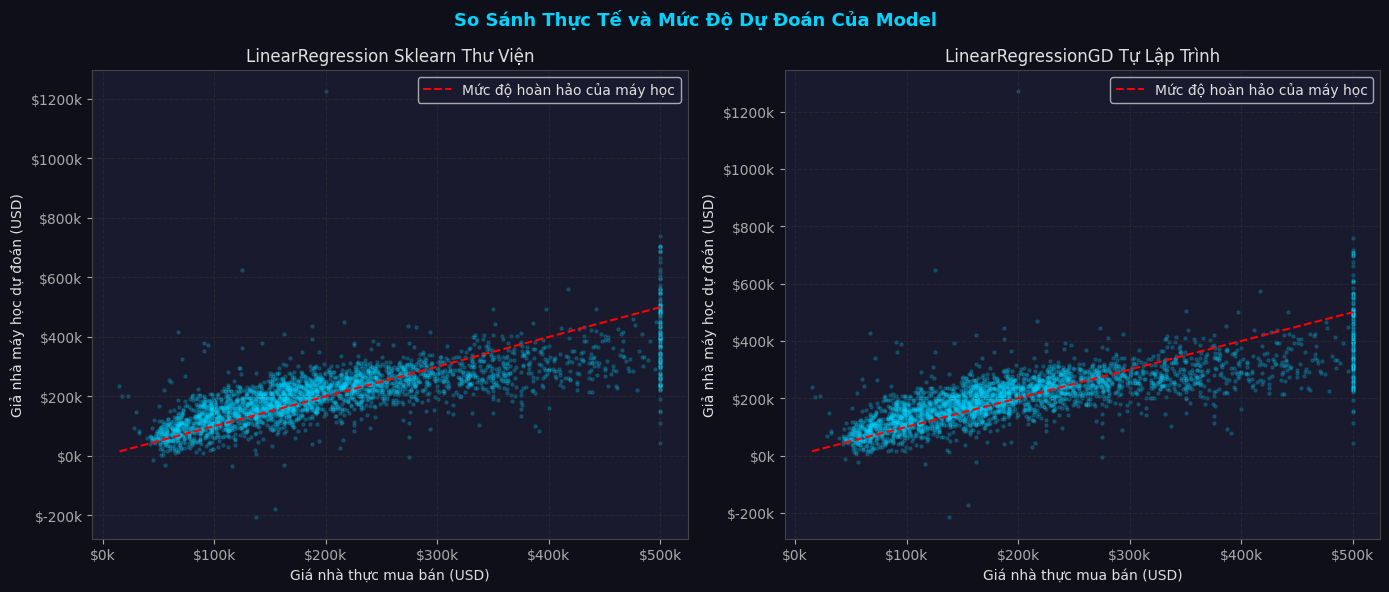

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('So Sánh Thực Tế và Mức Độ Dự Đoán Của Model', fontsize=13, fontweight='bold', color='#00d4ff')
pairs = [(y_pred_test, 'LinearRegression Sklearn Thư Viện'),
         (gd_model.predict(X_test_s), 'LinearRegressionGD Tự Lập Trình')]
for ax, (preds, title) in zip(axes, pairs):
    ax.scatter(y_test, preds, alpha=0.2, s=5, color='#00d4ff')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Mức độ hoàn hảo của máy học')
    ax.set_title(title); ax.set_xlabel('Giá nhà thực mua bán (USD)'); ax.set_ylabel('Giả nhà máy học dự đoán (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('plots/07_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Phân Tích Phần Dư Độ Lệch (Residuals Khác Biệt)


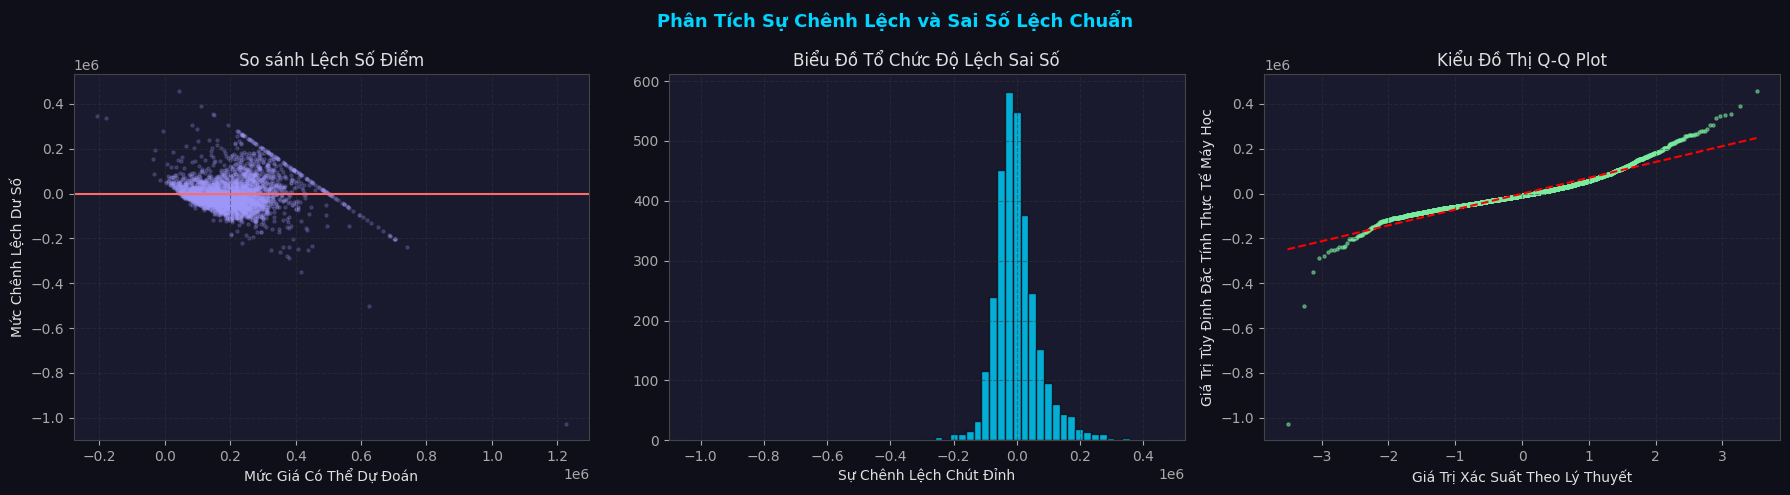

Mức khác biệt lệch giữa giá thực - Trung Bình: -725.07 | Mức dao động chuẩn: 74,360.46


In [47]:
residuals = y_test.values - y_pred_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân Tích Sự Chênh Lệch và Sai Số Lệch Chuẩn', fontsize=13, fontweight='bold', color='#00d4ff')

axes[0].scatter(y_pred_test, residuals, alpha=0.2, s=5, color='#a29bfe')
axes[0].axhline(0, color='#ff6b6b', lw=1.5)
axes[0].set_title('So sánh Lệch Số Điểm'); axes[0].set_xlabel('Mức Giá Có Thể Dự Đoán'); axes[0].set_ylabel('Mức Chênh Lệch Dư Số'); axes[0].grid(True)

axes[1].hist(residuals, bins=60, color='#00d4ff', alpha=0.8, edgecolor='#0a0a1a')
axes[1].set_title('Biểu Đồ Tổ Chức Độ Lệch Sai Số'); axes[1].set_xlabel('Sự Chênh Lệch Chút Đỉnh'); axes[1].grid(True)

(osm, osr), (slope, intercept, r) = sc_stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, s=5, color='#7bed9f', alpha=0.5)
axes[2].plot([min(osm), max(osm)], [slope*min(osm)+intercept, slope*max(osm)+intercept], 'r--')
axes[2].set_title('Kiểu Đồ Thị Q-Q Plot'); axes[2].set_xlabel('Giá Trị Xác Suất Theo Lý Thuyết'); axes[2].set_ylabel('Giá Trị Tùy Định Đặc Tính Thực Tế Máy Học'); axes[2].grid(True)

plt.tight_layout()
plt.savefig('plots/08_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mức khác biệt lệch giữa giá thực - Trung Bình: {residuals.mean():,.2f} | Mức dao động chuẩn: {residuals.std():,.2f}')


## 8. Lưu & Tải Mô Hình Lên Server Để Dùng
### 8.1 Lưu Bộ Công Cụ Pipeline (Chuẩn Hóa Dữ Liệu + Phương Trình Thuật Toán)
Lưu toàn bộ công cụ này dưới dạng `.joblib` để chống rò rỉ dữ liệu khi phát hành web ứng dụng thực tế.


In [48]:
# Lưu thư viện pipeline Sklearn đóng gói
final_pipeline = Pipeline([('scaler', scaler), ('lr', lr_model)])
joblib.dump(final_pipeline, 'models/lr_pipeline.joblib')
print('Đã lưu thành công: models/lr_pipeline.joblib')

# Lưu hệ tọa độ tự lập trình bằng tay Gradient Descent Numpy
gd_params = {
    'W': gd_model.W, 'b': gd_model.b,
    'feature_names': X.columns.tolist(),
    'scaler_mean': scaler.mean_, 'scaler_std': scaler.scale_
}
joblib.dump(gd_params, 'models/lr_gd_params.joblib')
print('Đã lưu thành công tọa độ tham số GD gốc: models/lr_gd_params.joblib')

for fp in ['models/lr_pipeline.joblib', 'models/lr_gd_params.joblib']:
    print(f'  {fp}: {os.path.getsize(fp)/1024:.1f} KB')


Đã lưu thành công: models/lr_pipeline.joblib
Đã lưu thành công tọa độ tham số GD gốc: models/lr_gd_params.joblib
  models/lr_pipeline.joblib: 2.2 KB
  models/lr_gd_params.joblib: 1.1 KB


### 8.2 Tải & Kiểm Tra Biến Số Dự Đoán Thử


In [49]:
loaded_pipe = joblib.load('models/lr_pipeline.joblib')

sample_idx = np.random.choice(len(X_test), 5, replace=False)
X_sample   = X_test.iloc[sample_idx]
y_sample   = y_test.iloc[sample_idx]
y_pred_s   = loaded_pipe.predict(X_sample)

print(f'{'Mã STT Index':>15} | {"Mức Giá Lịch Sử":>18} | {"Mức Giá Của AI":>18} | {"Tiền Lệch Tối Thiểu":>22}')
print('-'*80)
for i, (a, p) in enumerate(zip(y_sample, y_pred_s)):
    print(f'{sample_idx[i]:>15} | ${a:>17,.0f} | ${p:>17,.0f} | ${abs(a-p):>21,.0f}')
print(f'\nMô hình phát trực tuyến load thành công! Trọng Số Chính Xác Tỷ Lệ Giải Thích Biến Động R2 = {r2_score(y_sample, y_pred_s):.4f}')


   Mã STT Index |    Mức Giá Lịch Sử |     Mức Giá Của AI |    Tiền Lệch Tối Thiểu
--------------------------------------------------------------------------------
            865 | $           52,700 | $           97,263 | $               44,563
           1219 | $          360,500 | $          263,235 | $               97,265
            490 | $           95,800 | $          131,036 | $               35,236
            990 | $          164,000 | $          232,738 | $               68,738
           2356 | $          167,700 | $          199,769 | $               32,069

Mô hình phát trực tuyến load thành công! Trọng Số Chính Xác Tỷ Lệ Giải Thích Biến Động R2 = 0.6682


## 9. Tổng Kết Báo Cáo Cuối Cùng


In [50]:
print('='*80)
print('          TỔNG KẾT BẢNG VÀNG THÀNH TÍCH MÁY HỌC - TẬP XÁC ĐỊNH SỐ LIỆU KIỂM THỬ')
print('='*80)
print(f'  Lỗi Điểm Ảnh (MSE)       : {test_mse:>19,.2f}')
print(f'  Sai Lỗi Thực Tế Đơn Vị (RMSE): {test_rmse:>15,.2f} Số Tiền USD')
print(f'  Trọng Số Phẳng Lệch Điểm (MAE) : {test_mae:>13,.2f} Trừ Cập Nhập Số Tiền USD')
print(f'  Chỉ Tiêu Tỷ Lệ Đạt R2        : {test_r2:>19.4f}')
print('='*80)
print(f'✨ Thông số máy học tự hiểu ra và giải nghĩa được {test_r2*100:.1f}% mọi hiện tượng biến đổi tăng giảm của toàn bộ giá nhà toàn tiểu bang California!')
print(f'📌 Khi bạn nhập vị trí bất kỳ, thuật toán AI sai lệch thông báo xê dịch khoảng mức giá ~${test_mae:,.0f} Đô la Mỹ tiền thật.')


          TỔNG KẾT BẢNG VÀNG THÀNH TÍCH MÁY HỌC - TẬP XÁC ĐỊNH SỐ LIỆU KIỂM THỬ
  Lỗi Điểm Ảnh (MSE)       :    5,530,003,286.62
  Sai Lỗi Thực Tế Đơn Vị (RMSE):       74,363.99 Số Tiền USD
  Trọng Số Phẳng Lệch Điểm (MAE) :     51,860.26 Trừ Cập Nhập Số Tiền USD
  Chỉ Tiêu Tỷ Lệ Đạt R2        :              0.5780
✨ Thông số máy học tự hiểu ra và giải nghĩa được 57.8% mọi hiện tượng biến đổi tăng giảm của toàn bộ giá nhà toàn tiểu bang California!
📌 Khi bạn nhập vị trí bất kỳ, thuật toán AI sai lệch thông báo xê dịch khoảng mức giá ~$51,860 Đô la Mỹ tiền thật.


### Nhận Xét & Hướng Cải Thiện Cho Dự Án Nâng Cao Trí Tuệ

| Vấn Đề Gặp Phải | Mô Tả Hiện Trạng | Giải Pháp Chiến Lược Bổ Sung Căn Bản Định Hướng |
|-----------------|------------------|-------------------------------------------------|
| **Cắt bỏ Nóc Căn Nhà Thượng Đế** | Biểu đồ lịch sử bị "nhốt lồng giới hạn chốt đỉnh" ở mức \$500,000 khiến mô hình bị oan ức do sự kỳ thị cao điểm | Phải loại dữ liệu này tận gốc hoặc tự tay nâng thang đo dữ liệu bị lỗi |
| **Bé Nhỏ Tỷ Lệ Thẳng (Lệch Tâm Tuyến Tính)** | Phương trình bậc 1 khó đo vẽ mô phỏng tự nhiên độ lớn của Trái Đất và môi trường đại dương | Chạy Hàm Đa Thức Kép Polynomial Features hoặc chạy Kỹ thuật co rút Linear Elastic Net (Ridge/Lasso Classifier Regression) |
| Giải Định Cấu Hình Ngoài Lề (Outliers) | Một căn hộ bé xíu nhưng nhốt lộn vài ba trăm nhân mạng chằng hạn gây lỗi AI hoảng hốt | RobustScaler hoặc Xóa Biến Biến Biến Biến Nâng Winsorization |
| Linear Regression Máy Cơ Sở Thật Sự | Công thức này chỉ là bước căn bản vỡ lòng ở cấp độ máy điện tử sơ khai | Áp dụng mạng Neural Network Siêu Tốc hoặc Phương Tố XGBoost Classifier Nâng Đẳng Số Sức Mạnh Đột Phá |

### Cấu Trúc Toàn Bộ Dự Án Mã Nguồn Mở Tích Hợp Thư Mục
```
Chuyen_Muc_Gia_Tri_Gia_Nha_LinearRegression/
├── data/
│   └── housing.csv              # File văn bản chép lịch sử gốc của máy tính gốc định lý
├── models/
│   ├── lr_pipeline.joblib       # Đường ống chuẩn bị kỹ năng tự nhận chẩn đoán và chữa số liệu cực đỉnh Sklearn Pipeline (Scaler + Model)
│   └── lr_gd_params.joblib      # Phương thức thủ công tính điểm tối điểm chốt chóp tọa độ ròng lưu tay Gradient Descent
└── plots/                       # 8 biểu đồ định vị tọa độ phân tính (Chứa Các Cột Đồ Thị PNG sắc nét HD)
    ├── 01_target_distribution.png
    ├── 02_geo_map.png
    ├── 03_correlation_matrix.png
    ├── 04_ocean_proximity.png
    ├── 05_coefficients.png
    ├── 06_learning_curves.png
    ├── 07_pred_vs_actual.png
    └── 08_residuals.png
```
---
*Bộ mã khoa học phát kiến xây dựng từ [necromuralist.github.io](https://necromuralist.github.io/machine-learning-studies/posts/california-housing-prices/) tích hợp qua bộ nhớ thư viện GitHub Aurélien Géron*
